In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('IPL.csv')

# Drop unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Fix date
df['date'] = pd.to_datetime(df['date'])

# Fill common nulls
df['wicket_kind'] = df['wicket_kind'].fillna('none')
df['extra_type'] = df['extra_type'].fillna('none')
df['player_out'] = df['player_out'].fillna('none')
df['fielders'] = df['fielders'].fillna('none')
df['method'] = df['method'].fillna('none')

/tmp/ipykernel_69501/3739332908.py:4: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('IPL.csv')


In [3]:
# Get match-level static info (same for all balls in a match)
match_info = df.groupby('match_id').first().reset_index()[[
    'match_id', 'date', 'batting_team', 'bowling_team',
    'toss_winner', 'toss_decision', 'venue', 'city',
    'season', 'match_won_by', 'win_outcome', 'result_type',
    'day', 'month', 'year', 'stage'
]]

# Innings totals
innings_stats = df.groupby(['match_id', 'innings']).agg(
    total_runs=('runs_total', 'sum'),
    total_wickets=('striker_out', 'sum'),
    total_balls=('valid_ball', 'sum')
).reset_index()

# Pivot so innings1 and innings2 are columns
inn1 = innings_stats[innings_stats['innings'] == 1].rename(
    columns={'total_runs': 'inn1_runs', 'total_wickets': 'inn1_wickets', 'total_balls': 'inn1_balls'}
).drop('innings', axis=1)

inn2 = innings_stats[innings_stats['innings'] == 2].rename(
    columns={'total_runs': 'inn2_runs', 'total_wickets': 'inn2_wickets', 'total_balls': 'inn2_balls'}
).drop('innings', axis=1)

match_df = match_info.merge(inn1, on='match_id', how='left')
match_df = match_df.merge(inn2, on='match_id', how='left')

print(f"Match-level shape: {match_df.shape}")  # ~1000-1200 rows

Match-level shape: (1169, 22)


In [4]:
# Target: did batting_team (inn1) win?
match_df['target'] = (match_df['match_won_by'] == match_df['batting_team']).astype(int)

# Toss feature: did toss winner choose to bat?
match_df['toss_bat'] = (
    (match_df['toss_winner'] == match_df['batting_team']) & 
    (match_df['toss_decision'] == 'bat')
).astype(int)

# Run rate features
match_df['inn1_rr'] = match_df['inn1_runs'] / (match_df['inn1_balls'] / 6 + 1e-6)
match_df['inn2_rr'] = match_df['inn2_runs'] / (match_df['inn2_balls'] / 6 + 1e-6)

# Rolling win rate per team (historical, prevents leakage)
match_df = match_df.sort_values('date')
match_df['team1_winrate'] = match_df.groupby('batting_team')['target'].transform(
    lambda x: x.shift(1).expanding().mean()
).fillna(0.5)

# Head-to-head win rate
match_df['h2h_key'] = match_df[['batting_team','bowling_team']].apply(
    lambda r: '_vs_'.join(sorted([r['batting_team'], r['bowling_team']])), axis=1
)
match_df['h2h_winrate'] = match_df.groupby('h2h_key')['target'].transform(
    lambda x: x.shift(1).expanding().mean()
).fillna(0.5)

In [10]:
from sklearn.preprocessing import LabelEncoder

features = [
    'inn1_runs', 'inn1_wickets', 'inn1_balls', 'inn1_rr',
    'toss_bat', 'team1_winrate', 'h2h_winrate',
    'batting_team', 'bowling_team', 'venue', 'stage'
]

le = LabelEncoder()
for col in ['batting_team', 'bowling_team', 'venue', 'stage']:
    match_df[col] = le.fit_transform(match_df[col].astype(str))

X = match_df[features].fillna(0)
y = match_df['target']
match_df['season'] = (
    match_df['season']
    .astype(str)                        # convert everything to string first
    .str.extract(r'(\d{4})')[0]         # pull 4-digit year (note the [0] to get Series)
    .astype(float)                      # float first to handle NaNs safely
    .astype('Int64')                    # nullable integer (capital I)
)

# Drop rows where season is still null
match_df.dropna(subset=['season'], inplace=True)

# Now safe to compare
train_mask = match_df['season'] < match_df['season'].max()
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")



Train: (1095, 11), Test: (74, 11)


In [6]:
# Check what season values look like
print(match_df['season'].unique())

['2007/08' '2009' 2009 '2009/10' '2011' 2011 2012 2013 2014 2015 2016 2017
 2018 2019 '2019' '2020/21' '2021' 2021 2022 2023 2024 2025]


In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Count class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"Class ratio: {ratio:.2f}")  # pass this to the model

model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=30,
    scale_pos_weight=ratio,    # balances the classes
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=25
)

print(f"Best iteration: {model.best_iteration}")
print(f"Best logloss:   {model.best_score:.4f}")

Class ratio: 1.23
[0]	validation_0-logloss:0.68353
[25]	validation_0-logloss:0.60593
[50]	validation_0-logloss:0.61080
[56]	validation_0-logloss:0.61050
Best iteration: 27
Best logloss:   0.6052


Accuracy:  0.689
F1 Score:  0.736
ROC-AUC:   0.848
              precision    recall  f1-score   support

           0       0.95      0.46      0.62        41
           1       0.59      0.97      0.74        33

    accuracy                           0.69        74
   macro avg       0.77      0.72      0.68        74
weighted avg       0.79      0.69      0.67        74



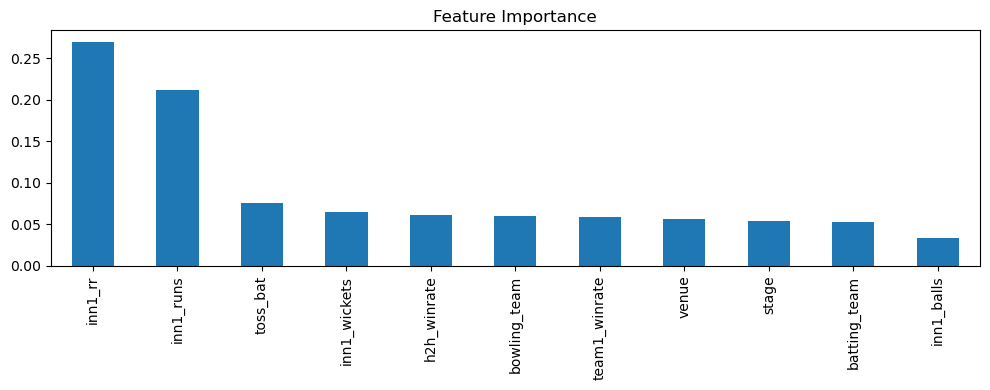

In [13]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}")
print(classification_report(y_test, y_pred))

# Feature importance plot
feat_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(10, 4), title='Feature Importance')
plt.tight_layout()
plt.show()